# Waste Classification - ResNet50 | Resume Clean + Warm OS Cache

Bản này dùng để **train tiếp sạch từ checkpoint cũ**:
- Load checkpoint/model cũ để tiếp tục từ epoch kế tiếp.
- Không resume W&B run cũ mặc định, tránh lỗi step lùi.
- Có thể re-log history cũ vào W&B run mới để chart nối đẹp.
- Giảm augmentation nặng để tránh epoch đầu sau resume bị kéo quá lâu.
- Cấu hình DataLoader an toàn hơn cho Kaggle T4.


In [1]:
# ============================================================
# Waste Classification Training Notebook - resnet50
# Full report artifact export
# Train from scratch: weights=None
# ============================================================

import os
import shutil
import json
import random
import time
from dataclasses import dataclass, asdict
from pathlib import Path
from PIL import Image
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

EXPECTED_CLASSES = [
    "Battery", "Biological", "Cardboard", "Clothes", "E_Waste",
    "Glass", "Metal", "Other", "Paper", "Plastic",
]

NUM_CLASSES = 10
IMG_SIZE = 224
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

@dataclass
class CFG:
    seed: int = 42
    model_name: str = "resnet50"
    weights: str = "None"          # train from scratch, giữ nguyên
    num_classes: int = 10
    image_size: int = 224

    # Local default. On Kaggle, auto-detect scans /kaggle/input.
    data_root: str = "/kaggle/input/datasets/nguynlonglb/pbl5-racthai-dut/splits"

    # Smoke test default. Increase after path/data sanity checks pass.
    epochs: int = 60
    batch_size: int = 48
    num_workers: int = 2  # Kaggle T4 safe default; thử 4 nếu RAM ổn
    lr: float = 1e-4               # giảm từ 2e-4
    weight_decay: float = 5e-4     # tăng L2 regularization
    min_lr: float = 1e-6

    patience: int = 12
    min_delta: float = 1e-4
    monitor: str = "val_macro_f1"

    use_amp: bool = True
    use_weighted_sampler: bool = False

    # Speed: pre-decode images to RAM to remove JPEG decode bottleneck.
    preload_to_ram: bool = False
    preload_size: int = 256
    preload_workers: int = 2

    # 49k images: avoid copying the full dataset to /dev/shm by default.
    # Warm OS page cache instead, then read from /kaggle/input with stable DataLoader workers.
    use_shm_cache: bool = False
    warm_os_cache: bool = True
    warm_os_cache_workers: int = 4

    persistent_workers: bool = True
    prefetch_factor: int = 2

    output_dir: str = "outputs_waste_resnet50_v2"

cfg = CFG()

# ============================================================
# Resume controls
# ============================================================
# Set this to a checkpoint from a previous Kaggle Output/Input version.
# Examples:
# RESUME_CKPT_PATH = "/kaggle/input/<old-output-dataset>/outputs_waste_resnet50_v2/checkpoints/best_model.pth"
# RESUME_CKPT_PATH = "/kaggle/input/<old-output-dataset>/outputs_waste_resnet50_v2/checkpoints/last_checkpoint.pth"
RESUME_CKPT_PATH = "/kaggle/input/models/nguynlonglb/66-trainresnet/other/default/1/best_model.pth"

# Optional: set this to previous training_history.csv so local curves continue from old epochs.
# Example:
# RESUME_HISTORY_CSV_PATH = "/kaggle/input/<old-output-dataset>/outputs_waste_resnet50_v2/tables/training_history.csv"
RESUME_HISTORY_CSV_PATH = "/kaggle/input/models/nguynlonglb/66-trainresnet/other/default/1/training_history.csv"

# W&B clean continuation.
# Keep this empty to create a new run and avoid step conflicts with old W&B runs.
# Only set an old run id if its latest step is strictly < start_epoch.
WANDB_RESUME_RUN_ID = ""
RELOG_HISTORY_TO_WANDB = True  # True only if starting a new W&B run but want to re-log old CSV rows.

seed_everything(cfg.seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Speed optimization for NVIDIA GPUs. Safe for CNN training on Kaggle T4.
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

OUTPUT_DIR = Path(cfg.output_dir)
if Path("/kaggle/working").exists():
    OUTPUT_DIR = Path("/kaggle/working") / cfg.output_dir

FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
CHECKPOINTS_DIR = OUTPUT_DIR / "checkpoints"
LOGS_DIR = OUTPUT_DIR / "logs"

for d in [OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, CHECKPOINTS_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

WORKLOG = []

def log_work(message: str):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"- [{timestamp}] {message}"
    WORKLOG.append(line)
    print(line)

def save_worklog():
    with open(LOGS_DIR / "worklog.md", "w", encoding="utf-8") as f:
        f.write(f"# Worklog - {cfg.model_name}\n\n")
        f.write("\n".join(WORKLOG))
        f.write("\n")

with open(LOGS_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(asdict(cfg), f, indent=2, ensure_ascii=False)

log_work("Initialized notebook config and output directories.")
print("Device:", DEVICE)
print("Output dir:", OUTPUT_DIR)
print(json.dumps(asdict(cfg), indent=2, ensure_ascii=False))

- [2026-06-05 18:24:52] Initialized notebook config and output directories.
Device: cuda
Output dir: /kaggle/working/outputs_waste_resnet50_v2
{
  "seed": 42,
  "model_name": "resnet50",
  "weights": "None",
  "num_classes": 10,
  "image_size": 224,
  "data_root": "/kaggle/input/datasets/nguynlonglb/pbl5-racthai-dut/splits",
  "epochs": 60,
  "batch_size": 48,
  "num_workers": 2,
  "lr": 0.0001,
  "weight_decay": 0.0005,
  "min_lr": 1e-06,
  "patience": 12,
  "min_delta": 0.0001,
  "monitor": "val_macro_f1",
  "use_amp": true,
  "use_weighted_sampler": false,
  "preload_to_ram": false,
  "preload_size": 256,
  "preload_workers": 2,
  "use_shm_cache": false,
  "warm_os_cache": true,
  "warm_os_cache_workers": 4,
  "persistent_workers": true,
  "prefetch_factor": 2,
  "output_dir": "outputs_waste_resnet50_v2"
}


In [2]:
# ============================================================
# W&B setup
# ============================================================
USE_WANDB = True
WANDB_PROJECT = "waste-classification"
WANDB_ENTITY = None

def setup_wandb():
    if not USE_WANDB:
        return None

    try:
        import os
        import wandb
        from kaggle_secrets import UserSecretsClient

        wandb_key = UserSecretsClient().get_secret("WANDB_API_KEY")
        os.environ["WANDB_API_KEY"] = wandb_key
        wandb.login(key=wandb_key)

        wandb_kwargs = dict(
            project=WANDB_PROJECT,
            entity=WANDB_ENTITY,
            name=f"{cfg.model_name}_resume_clean_waste10",
            config=asdict(cfg),
        )

        if WANDB_RESUME_RUN_ID:
            wandb_kwargs["id"] = WANDB_RESUME_RUN_ID
            wandb_kwargs["resume"] = "allow"
            print(f"🔁 W&B resume enabled for run id: {WANDB_RESUME_RUN_ID}")

        run = wandb.init(**wandb_kwargs)

        # Make charts use epoch as the x-axis. This keeps re-logged history and new epochs aligned.
        try:
            wandb.define_metric("epoch")
            wandb.define_metric("*", step_metric="epoch")
        except Exception as e:
            print("W&B define_metric skipped:", e)

        print("✅ W&B enabled:", run.name)
        return run

    except Exception as e:
        print("⚠️ W&B disabled:", e)
        return None

wandb_run = setup_wandb()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 102230357 (102230357-udn-com-co) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260605_182455-wximqb2a
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run resnet50_resume_clean_waste10
wandb: ⭐️ View project at https://wandb.ai/102230357-udn-com-co/waste-classification
wandb: 🚀 View run at https://wandb.ai/102230357-udn-com-co/waste-classification/runs/wximqb2a


✅ W&B enabled: resnet50_resume_clean_waste10


In [3]:
# ============================================================
# Dataset path resolver - fixed path for Kaggle
# ============================================================
DATA_ROOT = Path("/kaggle/input/datasets/nguynlonglb/pbl5-racthai-dut/splits")
cfg.data_root = str(DATA_ROOT)

def count_images_in_dir(path: Path) -> int:
    if not path.exists():
        return 0

    # Fast path for flat class folders: train/ClassName/*.jpg
    # Avoid Path.rglob("*") on Kaggle input because it is very slow on mounted datasets.
    count = 0
    with os.scandir(path) as it:
        for entry in it:
            if entry.is_file() and Path(entry.name).suffix.lower() in IMAGE_EXTS:
                count += 1
    return count

def looks_like_split_root(path: Path) -> bool:
    train_dir = path / "train"
    val_dir = path / "val"
    test_dir = path / "test"

    if not (train_dir.is_dir() and val_dir.is_dir() and test_dir.is_dir()):
        return False

    found = [c for c in EXPECTED_CLASSES if (train_dir / c).is_dir()]
    return len(found) == len(EXPECTED_CLASSES)

print("DATA_ROOT:", DATA_ROOT)
print("Exists:", DATA_ROOT.exists())
print("Valid split root:", looks_like_split_root(DATA_ROOT))

if not looks_like_split_root(DATA_ROOT):
    raise FileNotFoundError(
        f"Dataset root không đúng cấu trúc train/val/test đủ 10 class: {DATA_ROOT}"
    )

# ============================================================
# Optional /dev/shm RAM-disk copy - disabled by default for 49k images
# ============================================================
SHM_ROOT = Path("/dev/shm/waste_dataset")

def copy_dataset_to_shm(src: Path, dst: Path):
    if not Path("/dev/shm").exists():
        print("⚠️ /dev/shm không tồn tại, giữ DATA_ROOT gốc:", src)
        return src

    if dst.exists() and looks_like_split_root(dst):
        print(f"✅ Dataset đã có trong RAM disk: {dst} — skip copy")
        return dst

    if dst.exists():
        shutil.rmtree(dst)

    print(f"📦 Copying dataset to RAM disk: {src} -> {dst}")
    t0 = time.time()
    try:
        shutil.copytree(src, dst)
    except Exception as e:
        print("⚠️ Copy to /dev/shm failed, fallback to original DATA_ROOT:", e)
        return src

    dt = time.time() - t0
    if not looks_like_split_root(dst):
        print("⚠️ RAM disk copy không đúng cấu trúc, fallback to original DATA_ROOT.")
        return src

    print(f"✅ Dataset copied to RAM disk in {dt:.1f}s")
    return dst

if cfg.use_shm_cache and not cfg.preload_to_ram:
    DATA_ROOT = copy_dataset_to_shm(DATA_ROOT, SHM_ROOT)
else:
    print(f"ℹ️ Skip /dev/shm cache copy (use_shm_cache={cfg.use_shm_cache}, preload_to_ram={cfg.preload_to_ram})")

cfg.data_root = str(DATA_ROOT)

# Giữ num_workers từ CFG, không override cứng
# cfg.num_workers được giữ từ CFG để dễ tuning trên Kaggle T4

with open(LOGS_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(asdict(cfg), f, indent=2, ensure_ascii=False)

log_work(f"Using dataset root: {DATA_ROOT}")
log_work(f"num_workers set to {cfg.num_workers}. use_shm_cache={cfg.use_shm_cache}, warm_os_cache={cfg.warm_os_cache}")
save_worklog()

DATA_ROOT: /kaggle/input/datasets/nguynlonglb/pbl5-racthai-dut/splits
Exists: True
Valid split root: True
ℹ️ Skip /dev/shm cache copy (use_shm_cache=False, preload_to_ram=False)
- [2026-06-05 18:24:57] Using dataset root: /kaggle/input/datasets/nguynlonglb/pbl5-racthai-dut/splits
- [2026-06-05 18:24:57] num_workers set to 2. use_shm_cache=False, warm_os_cache=True


,class_name,train,val,test,total
0,Battery,661,141,143,945
1,Biological,2956,633,635,4224
2,Cardboard,623,133,135,891
3,Clothes,3726,798,800,5324
4,E_Waste,3698,792,794,5284
5,Glass,3565,764,765,5094
6,Metal,3726,798,799,5323
7,Other,7675,1644,1646,10965
8,Paper,3818,818,819,5455
9,Plastic,3822,819,820,5461


,item,value
0,dataset_root,/kaggle/input/datasets/nguynlonglb/pbl5-ractha...
1,num_classes,10
2,class_names,"Battery, Biological, Cardboard, Clothes, E_Was..."
3,train_images,34270
4,val_images,7340
5,test_images,7356
6,total_images,48966
7,created_at,2026-06-05T18:25:33


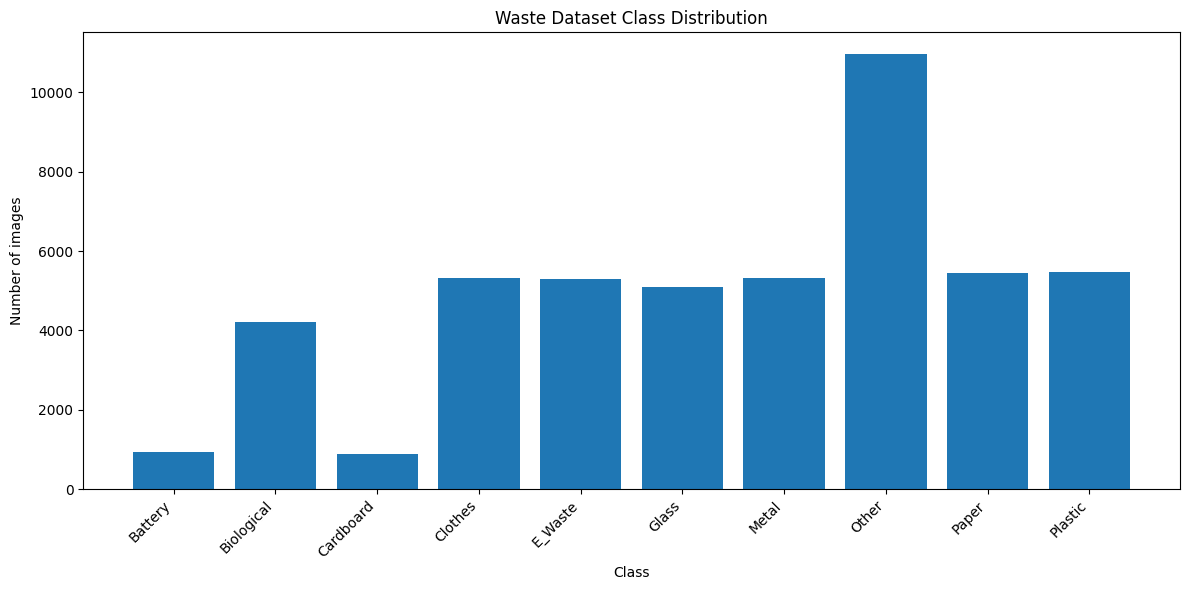

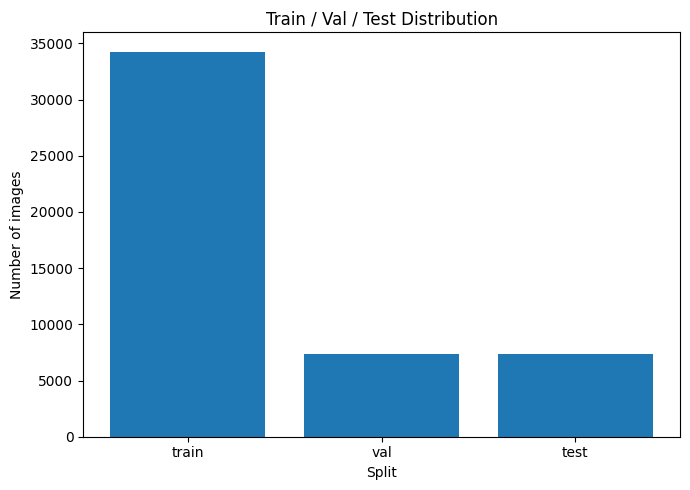

- [2026-06-05 18:25:33] Saved dataset_summary.csv, class_distribution.csv, class_distribution.png, train_val_test_distribution.png from real dataset.


In [4]:
# ============================================================
# Dataset tables and dataset-only figures
# These are created from the real Waste dataset, no training needed.
# ============================================================
def split_class_counts(split_root: Path) -> pd.DataFrame:
    rows = []
    for cls in EXPECTED_CLASSES:
        row = {"class_name": cls}
        for split in ["train", "val", "test"]:
            row[split] = count_images_in_dir(split_root / split / cls)
        row["total"] = row["train"] + row["val"] + row["test"]
        rows.append(row)
    return pd.DataFrame(rows)

class_distribution_df = split_class_counts(DATA_ROOT)
class_distribution_df.to_csv(TABLES_DIR / "class_distribution.csv", index=False, encoding="utf-8-sig")

dataset_summary_df = pd.DataFrame([
    {"item": "dataset_root", "value": str(DATA_ROOT)},
    {"item": "num_classes", "value": NUM_CLASSES},
    {"item": "class_names", "value": ", ".join(EXPECTED_CLASSES)},
    {"item": "train_images", "value": int(class_distribution_df["train"].sum())},
    {"item": "val_images", "value": int(class_distribution_df["val"].sum())},
    {"item": "test_images", "value": int(class_distribution_df["test"].sum())},
    {"item": "total_images", "value": int(class_distribution_df["total"].sum())},
    {"item": "created_at", "value": datetime.now().isoformat(timespec="seconds")},
])
dataset_summary_df.to_csv(TABLES_DIR / "dataset_summary.csv", index=False, encoding="utf-8-sig")

display(class_distribution_df)
display(dataset_summary_df)

plt.figure(figsize=(12, 6))
plt.bar(class_distribution_df["class_name"], class_distribution_df["total"])
plt.title("Waste Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

split_totals = class_distribution_df[["train", "val", "test"]].sum()
plt.figure(figsize=(7, 5))
plt.bar(split_totals.index, split_totals.values)
plt.title("Train / Val / Test Distribution")
plt.xlabel("Split")
plt.ylabel("Number of images")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "train_val_test_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

log_work("Saved dataset_summary.csv, class_distribution.csv, class_distribution.png, train_val_test_distribution.png from real dataset.")
save_worklog()

In [5]:
# ============================================================
# Dataloaders and model
# ============================================================
train_tfms = transforms.Compose([
    # Resume-clean augmentation: đủ regularization nhưng nhẹ hơn để tránh CPU/DataLoader bottleneck.
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.08, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ============================================================
# Optional RAM pre-decode dataset
# Removes JPEG decode bottleneck during training.
# ============================================================
def load_image_to_numpy(path: str, size: int = 256) -> np.ndarray:
    with Image.open(path) as img:
        img = img.convert("RGB").resize((size, size), Image.BILINEAR)
    return np.asarray(img, dtype=np.uint8)

def preload_imagefolder(folder: Path, size: int = 256, max_workers: int = 4):
    tmp_ds = datasets.ImageFolder(folder)
    samples = tmp_ds.samples
    classes = tmp_ds.classes
    class_to_idx = tmp_ds.class_to_idx

    print(f"Pre-loading {len(samples)} images from {folder} ...")
    t0 = time.time()

    paths = [path for path, _ in samples]
    labels = [label for _, label in samples]

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        images = list(ex.map(lambda p: load_image_to_numpy(p, size=size), paths))

    dt = time.time() - t0
    mem_mb = sum(img.nbytes for img in images) / 1e6
    print(f"  Done: {dt:.1f}s | {mem_mb:.0f} MB decoded images in RAM | {len(images)} images")

    return images, labels, samples, classes, class_to_idx

class PreloadedDataset(Dataset):
    def __init__(self, images, labels, samples, classes, class_to_idx, transform=None):
        self.images = images
        self.labels = labels
        self.targets = labels
        self.samples = samples
        self.classes = classes
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        if self.transform is not None:
            img = self.transform(img)
        return img, self.labels[idx]

if cfg.preload_to_ram:
    print("=== PRE-LOADING DATASETS INTO RAM ===")
    train_images, train_labels, train_samples, CLASS_NAMES, CLASS_TO_IDX = preload_imagefolder(
        DATA_ROOT / "train",
        size=cfg.preload_size,
        max_workers=cfg.preload_workers,
    )
    val_images, val_labels, val_samples, val_classes, _ = preload_imagefolder(
        DATA_ROOT / "val",
        size=cfg.preload_size,
        max_workers=cfg.preload_workers,
    )
    test_images, test_labels, test_samples, test_classes, _ = preload_imagefolder(
        DATA_ROOT / "test",
        size=cfg.preload_size,
        max_workers=cfg.preload_workers,
    )

    assert CLASS_NAMES == EXPECTED_CLASSES, f"Class mismatch: {CLASS_NAMES}"
    assert val_classes == CLASS_NAMES, f"Val class mismatch: {val_classes}"
    assert test_classes == CLASS_NAMES, f"Test class mismatch: {test_classes}"

    train_dataset = PreloadedDataset(train_images, train_labels, train_samples, CLASS_NAMES, CLASS_TO_IDX, transform=train_tfms)
    val_dataset = PreloadedDataset(val_images, val_labels, val_samples, CLASS_NAMES, CLASS_TO_IDX, transform=eval_tfms)
    test_dataset = PreloadedDataset(test_images, test_labels, test_samples, CLASS_NAMES, CLASS_TO_IDX, transform=eval_tfms)
else:
    train_dataset = datasets.ImageFolder(DATA_ROOT / "train", transform=train_tfms)
    val_dataset = datasets.ImageFolder(DATA_ROOT / "val", transform=eval_tfms)
    test_dataset = datasets.ImageFolder(DATA_ROOT / "test", transform=eval_tfms)

    CLASS_NAMES = train_dataset.classes
    CLASS_TO_IDX = train_dataset.class_to_idx


# ============================================================
# Warm OS page cache
# ============================================================
# Kaggle /kaggle/input can be slow when the OS cache is cold.
# This reads every image file once before training, so later DataLoader reads are served from RAM page cache when possible.
# It does NOT duplicate the dataset into /dev/shm, so it is safer for ~49k images.
def warm_os_page_cache(datasets_to_warm, max_workers: int = 4):
    paths = []
    for ds in datasets_to_warm:
        if hasattr(ds, "samples"):
            paths.extend([p for p, _ in ds.samples])

    # Remove duplicates while preserving order.
    paths = list(dict.fromkeys(paths))
    print(f"🔥 Warming OS page cache for {len(paths)} files with {max_workers} threads...")

    if not paths:
        print("ℹ️ No file paths found to warm. Skip.")
        return

    t0 = time.time()

    def _touch(path):
        with open(path, "rb") as f:
            while f.read(1024 * 1024):
                pass

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for _ in ex.map(_touch, paths):
            pass

    dt = time.time() - t0
    print(f"✅ OS page cache warm-up done in {dt:.1f}s")

if cfg.warm_os_cache and not cfg.preload_to_ram:
    warm_os_page_cache(
        [train_dataset, val_dataset, test_dataset],
        max_workers=cfg.warm_os_cache_workers,
    )
else:
    print(f"ℹ️ Skip OS cache warm-up (warm_os_cache={cfg.warm_os_cache}, preload_to_ram={cfg.preload_to_ram})")


assert len(CLASS_NAMES) == NUM_CLASSES, f"Expected {NUM_CLASSES} classes, got {len(CLASS_NAMES)}"
assert CLASS_NAMES == EXPECTED_CLASSES, f"Class order mismatch: {CLASS_NAMES}"

train_counts = np.bincount(np.array(train_dataset.targets), minlength=NUM_CLASSES)
class_weights_np = train_counts.sum() / (NUM_CLASSES * np.maximum(train_counts, 1))
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)

sampler = None
shuffle_train = True
if cfg.use_weighted_sampler:
    sample_weights = [class_weights[t].item() for t in train_dataset.targets]
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )
    shuffle_train = False

_loader_kwargs = dict(
    batch_size=cfg.batch_size,
    num_workers=cfg.num_workers,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(cfg.persistent_workers and cfg.num_workers > 0),
)

if cfg.num_workers > 0:
    _loader_kwargs["prefetch_factor"] = cfg.prefetch_factor

train_loader = DataLoader(
    train_dataset,
    shuffle=shuffle_train,
    sampler=sampler,
    **_loader_kwargs,
)
val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **_loader_kwargs,
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **_loader_kwargs,
)

def build_model(num_classes: int):
    if cfg.model_name == "resnet18":
        model = models.resnet18(weights=None)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, num_classes),
        )
    elif cfg.model_name == "resnet50":
        model = models.resnet50(weights=None)     # train from scratch
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=0.4),                    # chống overfit
            nn.Linear(in_features, num_classes),
        )
    else:
        raise ValueError(f"Unsupported model_name: {cfg.model_name}")
    return model

model = build_model(NUM_CLASSES).to(DEVICE)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs with DataParallel")
    model = nn.DataParallel(model)

def unwrap_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model

print("Model:", cfg.model_name)
print("weights=None: model architecture is scratch; checkpoint weights are loaded later if RESUME_CKPT_PATH is set.")
print("DataLoader kwargs:", _loader_kwargs)
print("Class weights:", class_weights_np)

log_work("Initialized dataloaders and model with weights=None.")
save_worklog()

🔥 Warming OS page cache for 48966 files with 4 threads...
✅ OS page cache warm-up done in 49.1s
Using 2 GPUs with DataParallel
Model: resnet50
weights=None: model architecture is scratch; checkpoint weights are loaded later if RESUME_CKPT_PATH is set.
DataLoader kwargs: {'batch_size': 48, 'num_workers': 2, 'pin_memory': True, 'persistent_workers': True, 'prefetch_factor': 2}
Class weights: [5.18456884 1.15933694 5.50080257 0.91975309 0.92671714 0.96129032
 0.91975309 0.44651466 0.89759036 0.89665097]
- [2026-06-05 18:26:36] Initialized dataloaders and model with weights=None.


In [6]:
# ============================================================
# Quick DataLoader speed check - optional
# ============================================================
# Để True nếu cần đo bottleneck. Nên chạy 1 lần trước khi train lâu.
if False:
    import time

    _t0 = time.time()
    _images, _labels = next(iter(train_loader))
    _dt = time.time() - _t0

    print(f"First train batch load time: {_dt:.3f}s")
    print("Batch shape:", tuple(_images.shape))
    print("Current DATA_ROOT:", DATA_ROOT)
    print("Current num_workers:", cfg.num_workers)
    print("Predecode status:", "ON" if cfg.preload_to_ram else "OFF")
    print("Warm OS cache:", "ON" if cfg.warm_os_cache else "OFF")


In [7]:
!ls /kaggle/input/notebooks/nguynlonglb/train-resnet50-49k-images-5-6

## Training
Chạy cell dưới để train thật. Mặc định `epochs=3` để smoke test. Sau khi ổn, tăng `cfg.epochs = 30`.

In [8]:
# ============================================================
# Train model
# This cell creates training-dependent artifacts only after real training.
# ============================================================
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1,
)
optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)
scaler = torch.amp.GradScaler("cuda", enabled=(cfg.use_amp and DEVICE.type == "cuda"))

class EarlyStopping:
    def __init__(self, patience=8, min_delta=1e-4, mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best = None
        self.bad_epochs = 0

    def step(self, value: float) -> bool:
        if self.best is None:
            self.best = value
            return False
        improved = value > self.best + self.min_delta if self.mode == "max" else value < self.best - self.min_delta
        if improved:
            self.best = value
            self.bad_epochs = 0
            return False
        self.bad_epochs += 1
        return self.bad_epochs >= self.patience

def run_one_epoch(loader, train: bool):
    model.train() if train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_true = []
    all_pred = []

    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=(cfg.use_amp and DEVICE.type == "cuda")):
                logits = model(images)
                loss = criterion(logits, labels)

            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

            preds = logits.argmax(dim=1)
            batch_size = images.size(0)

            total_loss += loss.item() * batch_size
            total_correct += (preds == labels).sum().item()
            total_samples += batch_size

            # Accumulate tensors and move to CPU once per batch without converting to Python lists.
            all_true.append(labels.detach().cpu())
            all_pred.append(preds.detach().cpu())

    all_true = torch.cat(all_true).numpy()
    all_pred = torch.cat(all_pred).numpy()

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    macro_f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(all_true, all_pred, average="weighted", zero_division=0)

    # Giải phóng RAM ngay sau khi tính xong metric
    del all_true, all_pred
    return avg_loss, acc, macro_f1, weighted_f1

def save_checkpoint(path: Path, epoch: int, metric: float):
    # Memory-safe checkpoint: model weights only.
    # We intentionally avoid saving AdamW optimizer state here because it is large and may kill Kaggle RAM.
    torch.save({
        "epoch": epoch,
        "model_state_dict": unwrap_model(model).state_dict(),
        "metric": metric,
        "class_names": CLASS_NAMES,
        "class_to_idx": CLASS_TO_IDX,
        "config": asdict(cfg),
        "weights": "None",
    }, path)



def save_last_checkpoint(epoch: int, best_metric: float, history: list):
    # Lightweight checkpoint for safe continuation.
    # Optimizer/scheduler/scaler states are not saved going forward to avoid RAM spikes.
    torch.save({
        "epoch": epoch,
        "model_state_dict": unwrap_model(model).state_dict(),
        "optimizer_state_dict": None,
        "scheduler_state_dict": None,
        "scaler_state_dict": None,
        "best_metric": best_metric,
        "history": history,
        "class_names": CLASS_NAMES,
        "class_to_idx": CLASS_TO_IDX,
        "cfg": asdict(cfg),
        "config": asdict(cfg),
        "weights": "None",
    }, CHECKPOINTS_DIR / "last_checkpoint.pth")



# Maximum train-time budget.
# Kaggle sessions are limited; stop safely before the session expires.
def _clean_state_dict(state_dict: dict) -> dict:
    clean = {}
    for k, v in state_dict.items():
        clean[k.replace("module.", "", 1) if k.startswith("module.") else k] = v
    return clean

def load_resume_checkpoint(path: Path):
    ckpt = torch.load(path, map_location=DEVICE)
    state_dict = ckpt.get("model_state_dict", ckpt)
    unwrap_model(model).load_state_dict(_clean_state_dict(state_dict), strict=True)

    # Load optimizer/scheduler/scaler only if the checkpoint contains them.
    if ckpt.get("optimizer_state_dict") is not None:
        try:
            optimizer.load_state_dict(ckpt["optimizer_state_dict"])
            print("Loaded optimizer state.")
        except Exception as e:
            print("Skip optimizer state:", e)

    if ckpt.get("scheduler_state_dict") is not None and scheduler is not None:
        try:
            scheduler.load_state_dict(ckpt["scheduler_state_dict"])
            print("Loaded scheduler state.")
        except Exception as e:
            print("Skip scheduler state:", e)

    if ckpt.get("scaler_state_dict") is not None and scaler is not None:
        try:
            scaler.load_state_dict(ckpt["scaler_state_dict"])
            print("Loaded AMP scaler state.")
        except Exception as e:
            print("Skip scaler state:", e)

    loaded_epoch = int(ckpt.get("epoch", 0))
    loaded_best = float(ckpt.get("best_metric", ckpt.get("metric", -1.0)))
    loaded_history = ckpt.get("history", [])

    print(f"✅ Loaded resume checkpoint: {path}")
    print(f"   previous_epoch={loaded_epoch} | previous_best_metric={loaded_best:.4f}")
    return loaded_epoch + 1, loaded_best, loaded_history

def load_resume_history_csv(path: Path):
    if not path.exists():
        print("Resume history CSV not found:", path)
        return []

    df = pd.read_csv(path)
    records = df.to_dict("records")
    print(f"✅ Loaded previous training history: {path} | rows={len(records)}")
    return records


MAX_TRAIN_HOURS = 11.0
TRAIN_START_TIME = time.time()
MAX_TRAIN_SECONDS = MAX_TRAIN_HOURS * 3600

history = []
best_metric = -1.0
start_epoch = 1

# 1) Load old CSV first, so local loss/accuracy curves continue from previous run.
if RESUME_HISTORY_CSV_PATH:
    history = load_resume_history_csv(Path(RESUME_HISTORY_CSV_PATH))
    if len(history) > 0 and "val_macro_f1" in history[0]:
        best_metric = max(float(row.get("val_macro_f1", -1.0)) for row in history)
        start_epoch = max(int(row.get("epoch", 0)) for row in history) + 1

# 2) Load checkpoint weights/state. This overrides start_epoch if checkpoint epoch is newer.
if RESUME_CKPT_PATH:
    ckpt_start_epoch, ckpt_best_metric, ckpt_history = load_resume_checkpoint(Path(RESUME_CKPT_PATH))
    start_epoch = max(start_epoch, ckpt_start_epoch)
    best_metric = max(best_metric, ckpt_best_metric)
    if len(history) == 0 and isinstance(ckpt_history, list) and len(ckpt_history) > 0:
        history = ckpt_history

early_stopper = EarlyStopping(cfg.patience, cfg.min_delta, mode="max")
if best_metric > 0:
    early_stopper.best = best_metric

print(f"Training will start at epoch {start_epoch}/{cfg.epochs}. Current best val_macro_f1={best_metric:.4f}")

# Optional: re-log old CSV rows into a new W&B run.
# Do NOT enable this when WANDB_RESUME_RUN_ID is set, because the old run already has those points.
if wandb_run is not None and RELOG_HISTORY_TO_WANDB and len(history) > 0 and not WANDB_RESUME_RUN_ID:
    import wandb
    old_rows = sorted(
        [dict(r) for r in history if "epoch" in r and int(r["epoch"]) < start_epoch],
        key=lambda r: int(r["epoch"]),
    )
    for old_row in old_rows:
        old_row["epoch"] = int(old_row["epoch"])
        wandb.log(old_row, step=old_row["epoch"])
    print(f"Re-logged {len(old_rows)} old history rows to new W&B run.")

for epoch in range(start_epoch, cfg.epochs + 1):
    epoch_start_time = time.time()

    train_loss, train_acc, train_macro_f1, train_weighted_f1 = run_one_epoch(train_loader, train=True)
    val_loss, val_acc, val_macro_f1, val_weighted_f1 = run_one_epoch(val_loader, train=False)

    scheduler.step(val_macro_f1)
    lr_now = optimizer.param_groups[0]["lr"]
    epoch_time_sec = time.time() - epoch_start_time

    row = {
        "epoch": epoch,
        "lr": lr_now,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_macro_f1": train_macro_f1,
        "train_weighted_f1": train_weighted_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1,
        "epoch_time_sec": epoch_time_sec,
    }
    
    if wandb_run is not None:
        import wandb
        wandb.log(row, step=epoch)
        
    history.append(row)

    save_checkpoint(CHECKPOINTS_DIR / "last_model.pth", epoch, val_macro_f1)
    # Lưu last_checkpoint mỗi 5 epoch để tránh I/O + RAM spike mỗi epoch
    if epoch % 5 == 0:
        save_last_checkpoint(epoch, best_metric, history[-20:])

    print(
        f"Epoch {epoch:03d}/{cfg.epochs} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_macro_f1={val_macro_f1:.4f} | "
        f"time={epoch_time_sec:.1f}s"
    )

    if val_macro_f1 > best_metric + cfg.min_delta:
        best_metric = val_macro_f1
        save_checkpoint(CHECKPOINTS_DIR / "best_model.pth", epoch, best_metric)
        pd.DataFrame(history).to_csv(TABLES_DIR / "training_history.csv", index=False, encoding="utf-8-sig")
        print(f"  -> Saved best_model.pth with val_macro_f1={best_metric:.4f}")

    elapsed = time.time() - TRAIN_START_TIME
    remaining = MAX_TRAIN_SECONDS - elapsed
    print(f"Elapsed: {elapsed/3600:.2f}h | Remaining train budget: {remaining/3600:.2f}h")

    # Giải phóng VRAM và RAM cuối mỗi epoch
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    import gc; gc.collect()          # thu dọn RAM Python (object chờ GC)
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    import gc; gc.collect()
    if remaining <= 0:
        print("Reached max training time budget. Stopping training safely.")
        break

    if early_stopper.step(val_macro_f1):
        print(f"Early stopping at epoch {epoch}. Best val_macro_f1={best_metric:.4f}")
        break

# Final save of complete training history after loop / early stopping.
pd.DataFrame(history).to_csv(TABLES_DIR / "training_history.csv", index=False, encoding="utf-8-sig")

history_df = pd.read_csv(TABLES_DIR / "training_history.csv")

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss Curve - {cfg.model_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "loss_curve.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="train_acc")
plt.plot(history_df["epoch"], history_df["val_acc"], label="val_acc")
plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="train_macro_f1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title(f"Accuracy / Macro-F1 Curve - {cfg.model_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "accuracy_curve.png", dpi=200, bbox_inches="tight")
plt.show()

log_work("Training finished. Saved best_model.pth, last_model.pth, training_history.csv, loss_curve.png, accuracy_curve.png from real training.")
save_worklog()

✅ Loaded previous training history: /kaggle/input/models/nguynlonglb/66-trainresnet/other/default/1/training_history.csv | rows=24
Loaded optimizer state.
Loaded scheduler state.
✅ Loaded resume checkpoint: /kaggle/input/models/nguynlonglb/66-trainresnet/other/default/1/best_model.pth
   previous_epoch=24 | previous_best_metric=0.7050
Training will start at epoch 25/60. Current best val_macro_f1=0.7050
Re-logged 24 old history rows to new W&B run.
Epoch 025/60 | train_loss=1.2483 train_acc=0.7575 | val_loss=1.5459 val_acc=0.7262 val_macro_f1=0.6942 | time=567.8s
Elapsed: 0.16h | Remaining train budget: 10.84h
Epoch 026/60 | train_loss=1.2025 train_acc=0.7762 | val_loss=1.4909 val_acc=0.7527 val_macro_f1=0.7212 | time=550.8s
  -> Saved best_model.pth with val_macro_f1=0.7212
Elapsed: 0.31h | Remaining train budget: 10.69h
Epoch 027/60 | train_loss=1.1773 train_acc=0.7910 | val_loss=1.5473 val_acc=0.7286 val_macro_f1=0.7013 | time=548.0s
Elapsed: 0.46h | Remaining train budget: 10.54h
Ep

## Evaluation / Report artifacts
Chạy sau khi đã có `best_model.pth`. Cell này không tạo confusion matrix hay prediction examples nếu chưa train/evaluate thật.

In [ ]:
# ============================================================
# Test evaluation and full report artifacts
# Creates confusion matrices, classification report, model_metrics, prediction examples.
# It refuses to create fake evaluation figures if best_model.pth is missing.
# ============================================================
# Optional: evaluate a checkpoint from a previous Kaggle Output/Input version.
# Example:
# EVAL_CKPT_PATH = "/kaggle/input/<old-output-dataset>/outputs_waste_resnet50_v2/checkpoints/best_model.pth"
EVAL_CKPT_PATH = ""

best_ckpt_path = Path(EVAL_CKPT_PATH) if EVAL_CKPT_PATH else (CHECKPOINTS_DIR / "best_model.pth")
if not best_ckpt_path.exists():
    log_work(f"SKIPPED evaluation artifacts: checkpoint missing: {best_ckpt_path}")
    save_worklog()
    raise FileNotFoundError(f"Checkpoint is missing: {best_ckpt_path}")

ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
state_dict = ckpt.get("model_state_dict", ckpt)
unwrap_model(model).load_state_dict(_clean_state_dict(state_dict), strict=True)
model.eval()
print("✅ Loaded checkpoint for evaluation:", best_ckpt_path)

test_raw_dataset = datasets.ImageFolder(DATA_ROOT / "test", transform=None)
assert test_raw_dataset.classes == CLASS_NAMES

@torch.no_grad()
def predict_test_set():
    total_loss = 0.0
    all_true, all_pred, all_prob = [], [], []
    filepaths = [p for p, _ in test_dataset.samples]

    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(cfg.use_amp and DEVICE.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)

        preds = probs.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        all_true.append(labels.detach().cpu())
        all_pred.append(preds.detach().cpu())
        all_prob.append(probs.detach().cpu())

    y_true = torch.cat(all_true).numpy()
    y_pred = torch.cat(all_pred).numpy()
    y_prob = torch.cat(all_prob).numpy()
    avg_loss = total_loss / len(test_loader.dataset)

    return avg_loss, y_true, y_pred, y_prob, filepaths

test_loss, y_true, y_pred, y_prob, test_filepaths = predict_test_set()

test_acc = accuracy_score(y_true, y_pred)
test_macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
test_weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

report = classification_report(
    y_true, y_pred, target_names=CLASS_NAMES, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(TABLES_DIR / "classification_report.csv", encoding="utf-8-sig")
display(report_df)

metrics_df = pd.DataFrame([{
    "model_name": cfg.model_name,
    "weights": "None",
    "test_loss": test_loss,
    "test_acc": test_acc,
    "test_macro_f1": test_macro_f1,
    "test_weighted_f1": test_weighted_f1,
    "best_checkpoint": str(best_ckpt_path),
}])
metrics_df.to_csv(TABLES_DIR / "model_metrics.csv", index=False, encoding="utf-8-sig")
display(metrics_df)

test_summary = metrics_df.iloc[0].to_dict()
test_summary["created_at"] = datetime.now().isoformat(timespec="seconds")
with open(LOGS_DIR / "test_summary.json", "w", encoding="utf-8") as f:
    json.dump(test_summary, f, indent=2, ensure_ascii=False)

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {cfg.model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
plt.yticks(np.arange(NUM_CLASSES), CLASS_NAMES)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8)
plt.colorbar()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

cm_norm = cm.astype(np.float64) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
plt.figure(figsize=(10, 8))
plt.imshow(cm_norm, vmin=0, vmax=1)
plt.title(f"Normalized Confusion Matrix - {cfg.model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
plt.yticks(np.arange(NUM_CLASSES), CLASS_NAMES)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_normalized.png", dpi=200, bbox_inches="tight")
plt.show()

per_class_f1 = report_df.loc[CLASS_NAMES, "f1-score"].astype(float)
plt.figure(figsize=(12, 5))
plt.bar(per_class_f1.index, per_class_f1.values)
plt.ylim(0, 1.05)
plt.title(f"Per-Class F1 Score - {cfg.model_name}")
plt.xlabel("Class")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "per_class_f1_score.png", dpi=200, bbox_inches="tight")
plt.show()

pred_df = pd.DataFrame({
    "filepath": test_filepaths,
    "true_idx": y_true,
    "pred_idx": y_pred,
    "confidence": y_prob.max(axis=1),
})
pred_df["true_label"] = pred_df["true_idx"].map(lambda x: CLASS_NAMES[int(x)])
pred_df["pred_label"] = pred_df["pred_idx"].map(lambda x: CLASS_NAMES[int(x)])
pred_df["correct"] = pred_df["true_idx"] == pred_df["pred_idx"]
pred_df.to_csv(TABLES_DIR / "test_predictions.csv", index=False, encoding="utf-8-sig")

def plot_prediction_examples(df: pd.DataFrame, correct: bool, save_name: str, max_images: int = 9):
    subset = df[df["correct"] == correct].copy()
    if subset.empty:
        log_work(f"SKIPPED {save_name}: no {'correct' if correct else 'wrong'} predictions available.")
        return

    subset = subset.sort_values("confidence", ascending=False).head(max_images)
    n = len(subset)
    cols = 3
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 4, rows * 4))

    for i, (_, row) in enumerate(subset.iterrows(), start=1):
        img = test_raw_dataset.loader(row["filepath"]).convert("RGB")
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")
        title = (
            f"True: {row['true_label']}\n"
            f"Pred: {row['pred_label']}\n"
            f"Conf: {row['confidence']:.2f}"
        )
        plt.title(title, fontsize=9)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / save_name, dpi=200, bbox_inches="tight")
    plt.show()
    log_work(f"Saved {save_name} from real test-set inference.")

plot_prediction_examples(pred_df, correct=True, save_name="prediction_examples_correct.png")
plot_prediction_examples(pred_df, correct=False, save_name="prediction_examples_wrong.png")

log_work("Saved evaluation artifacts from real test set: confusion matrices, per-class F1, prediction examples, classification_report.csv, model_metrics.csv, test_summary.json.")
save_worklog()

In [ ]:
# ============================================================
# Upload report artifacts to W&B
# ============================================================
if wandb_run is not None:
    import wandb

    # Log final test metrics
    wandb.log({
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_macro_f1": test_macro_f1,
        "test_weighted_f1": test_weighted_f1,
    })

    # Log images
    for img_path in [
        FIGURES_DIR / "class_distribution.png",
        FIGURES_DIR / "train_val_test_distribution.png",
        FIGURES_DIR / "loss_curve.png",
        FIGURES_DIR / "accuracy_curve.png",
        FIGURES_DIR / "confusion_matrix.png",
        FIGURES_DIR / "confusion_matrix_normalized.png",
        FIGURES_DIR / "per_class_f1_score.png",
        FIGURES_DIR / "prediction_examples_correct.png",
        FIGURES_DIR / "prediction_examples_wrong.png",
    ]:
        if img_path.exists():
            wandb.log({img_path.stem: wandb.Image(str(img_path))})
        else:
            print("Missing figure, skip:", img_path)

    # Upload all files as W&B artifact
    artifact = wandb.Artifact(
        name=f"{cfg.model_name}_waste10_report_outputs",
        type="report-assets",
    )

    for folder in [FIGURES_DIR, TABLES_DIR, CHECKPOINTS_DIR, LOGS_DIR]:
        if folder.exists():
            artifact.add_dir(str(folder), name=folder.name)

    wandb_run.log_artifact(artifact)

    print("✅ Uploaded figures/tables/checkpoints/logs to W&B")

In [ ]:
# ============================================================
# Artifact inventory / sanity check
# Does not create fake files. It reports what exists and what is missing.
# ============================================================
required_files = {
    "FIGURES": [
        FIGURES_DIR / "class_distribution.png",
        FIGURES_DIR / "train_val_test_distribution.png",
        FIGURES_DIR / "loss_curve.png",
        FIGURES_DIR / "accuracy_curve.png",
        FIGURES_DIR / "confusion_matrix.png",
        FIGURES_DIR / "confusion_matrix_normalized.png",
        FIGURES_DIR / "per_class_f1_score.png",
        FIGURES_DIR / "prediction_examples_correct.png",
        FIGURES_DIR / "prediction_examples_wrong.png",
    ],
    "TABLES": [
        TABLES_DIR / "dataset_summary.csv",
        TABLES_DIR / "class_distribution.csv",
        TABLES_DIR / "training_history.csv",
        TABLES_DIR / "classification_report.csv",
        TABLES_DIR / "model_metrics.csv",
    ],
    "CHECKPOINTS": [
        CHECKPOINTS_DIR / "best_model.pth",
        CHECKPOINTS_DIR / "last_model.pth",
        CHECKPOINTS_DIR / "last_checkpoint.pth",
    ],
    "LOGS": [
        LOGS_DIR / "config.json",
        LOGS_DIR / "test_summary.json",
        LOGS_DIR / "worklog.md",
    ],
}

inventory_rows = []
for group, files in required_files.items():
    for path in files:
        inventory_rows.append({
            "group": group,
            "file": path.name,
            "path": str(path),
            "exists": path.exists(),
            "size_bytes": path.stat().st_size if path.exists() else 0,
        })

inventory_df = pd.DataFrame(inventory_rows)
inventory_df.to_csv(OUTPUT_DIR / "artifact_inventory.csv", index=False, encoding="utf-8-sig")
display(inventory_df)

missing = inventory_df[~inventory_df["exists"]]
if len(missing) > 0:
    log_work("Missing artifacts detected. This is expected if training/evaluation cells have not been run.")
    for _, row in missing.iterrows():
        log_work(f"MISSING {row['group']}: {row['file']}")
else:
    log_work("All requested report artifacts exist.")

save_worklog()
print("Artifact inventory saved:", OUTPUT_DIR / "artifact_inventory.csv")

if wandb_run is not None:
    wandb_run.finish()